# Trabalho 1 — Modelagem com Árvore de Decisão e Ensembles

Nome do Aluno 1: Anderson Cardoso  
N°Pece: 119896

Este exercício utiliza a base **Bank Marketing (UCI)**, composta por dados de campanhas de telemarketing de um banco português realizadas entre 2008 e 2010. Cada registro descreve características do cliente, do contato realizado e do contexto da campanha, e o objetivo é prever se o cliente contratará um depósito a prazo (y ∈ {yes, no}).

## Parte 1 - Análise Exploratória de Dados

Antes de qualquer modelagem, é necessário construir uma compreensão sólida da base de dados em estudo. Nesta etapa, precisamos: verificar a estrutura da base (dimensões, tipos), a distribuição do alvo e o desbalanceamento, mapear a qualidade dos dados, avaliar a cardinalidade das variáveis categóricas e o comportamento das numéricas, inspecionar a dimensão temporal e identificar riscos de vazamento de informação (data leakage).

Para implementar esta análise, você deverá responder as perguntas abaixo. Além da resposta por extenso, você deve apresentar o código que usou para encontrar a resposta. Sempre que possível, adicione comentários nas linhas de código para ajudar o professor na correção

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    average_precision_score
)

# O CSV da UCI usa ponto e vírgula como separador
df = pd.read_csv("bank-additional-full.csv", sep=";")

# Mostrar as primeiras linhas
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 1.1 Quantas linhas e colunas há no dataset? Alguma coluna é constante (valor único)?

Resposta:<br>
O dataset Bank Marketing contém '41188' linhas e '21' colunas. <br>
Quantidade de colunas constantes: 0


In [2]:
colunas = len(df.columns)
linhas = len(df)
constante = []
for i in df.columns:
    if len(df[i].unique()) <=1:
        print(f'coluna: {i}, key: {df[i].unique()}')
        constante.append(i)
    
print(
    f"O dataset Bank Marketing contém "
    f"'{linhas}' linhas e '{colunas}' colunas. "
    f"\nQuantidade de colunas constantes: {len(constante)}"
)

O dataset Bank Marketing contém '41188' linhas e '21' colunas. 
Quantidade de colunas constantes: 0


### 1.2 Quais são os tipos de dados por coluna? Há algo que deveria ser numérico e veio como texto?

Resposta:
```text
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 18  euribor3m       41188 non-null  float64
 19  nr.employed     41188 non-null  float64
 20  y               41188 non-null  str   
```

dtypes: float64(5), int64(5), str(11) <br>
Uma amostra com 10 registros foi utilizada para verificar se os valores armazenados nas colunas são compativeis com seus respectivos tipos. Com isso, é possivel verificar que os tipos são consistentes com os valores observados na amostra.

In [3]:
df.info()
pd.set_option('display.max_columns', None)
df.head(10)


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### 1.3 Em relação à variável alvo (target), qual a distribuição de classes (yes vs no) em contagem e proporção?

Resposta:
```text
Coluna Target: Y
Classe: NO Proporção: 88.73%
Classe: YES Proporção: 11.27%
```

In [4]:
proporção = df["y"].value_counts(normalize=True).mul(100).round(2)

print("Coluna Target: Y")
for k, v in proporção.items():
    print(f"Classe: {k.upper()} Proporção: {v}%")


Coluna Target: Y
Classe: NO Proporção: 88.73%
Classe: YES Proporção: 11.27%


### 1.4 Essa proporção sugere desbalanceamento? Se sim, quais métricas de avaliação de desempenho serão mais adequadas (e por quê)?

Resposta:

```text
Sim. A variável 'Y' apresenta desenbalanceamento, com 88.73% dos registros classificados como 'NO' e 11.27% como 'YES'.
Esse desbalanceamento deve ser considerado durante a etapa de modelagem, pois pode fazer com que o modelo tenha maior dificuldade em identificar corretamente a classe minoritária. Por esse motivo, métricas como Recall e F1-score serão importantes para avaliar o desempenho do modelo.
```

### 1.5 Qual a cardinalidade (número de categorias distintas) de cada coluna categórica? Liste da maior para a menor.

Resposta:
```text
Colunas categóricas em ordem desc.

job            12
month          10
education       8
day_of_week     5
marital         4
default         3
housing         3
poutcome        3
loan            3
contact         2
y               2
```

In [5]:
#Insira seu código aqui
categoricas = df.select_dtypes(include="str").nunique().sort_values(ascending=False)

print(categoricas)

job            12
month          10
education       8
day_of_week     5
marital         4
default         3
housing         3
poutcome        3
loan            3
contact         2
y               2
dtype: int64


### 1.6 Mostre estatísticas descritivas (min/mediana/média/p95) para as variáveis numéricas.

Resposta:<br>
P95: Percentil 95 (0.95 ou 0.95%)

| Variável | Min | Mediana | Média | P95 |
|---|---:|---:|---:|---:|
| age | 17.000 | 38.000 | 40.024 | 58.000 |
| duration | 0.000 | 180.000 | 258.285 | 752.650 |
| campaign | 1.000 | 2.000 | 2.568 | 7.000 |
| pdays | 0.000 | 999.000 | 962.475 | 999.000 |
| previous | 0.000 | 0.000 | 0.173 | 1.000 |
| emp.var.rate | -3.400 | 1.100 | 0.082 | 1.400 |
| cons.price.idx | 92.201 | 93.749 | 93.576 | 94.465 |
| cons.conf.idx | -50.800 | -41.800 | -40.503 | -33.600 |
| euribor3m | 0.634 | 4.857 | 3.621 | 4.966 |
| nr.employed | 4963.600 | 5191.000 | 5167.036 | 5228.100 |




In [6]:
#Insira seu código aqui
variaveis_numericas = df.select_dtypes(exclude="str")
estatistica = variaveis_numericas.agg(['min', 'median','mean']).T
estatistica['P95'] = variaveis_numericas.quantile(0.95)

print("| Variável | Min | Mediana | Média | P95 |")
print("|---|---:|---:|---:|---:|")

for index, row in estatistica.iterrows():
    print(
        f"| {index} | "\
        f"{row['min']:.3f} | "\
        f"{row['median']:.3f} | "\
        f"{row['mean']:.3f} | " \
        f"{row['P95']:.3f} |")

| Variável | Min | Mediana | Média | P95 |
|---|---:|---:|---:|---:|
| age | 17.000 | 38.000 | 40.024 | 58.000 |
| duration | 0.000 | 180.000 | 258.285 | 752.650 |
| campaign | 1.000 | 2.000 | 2.568 | 7.000 |
| pdays | 0.000 | 999.000 | 962.475 | 999.000 |
| previous | 0.000 | 0.000 | 0.173 | 1.000 |
| emp.var.rate | -3.400 | 1.100 | 0.082 | 1.400 |
| cons.price.idx | 92.201 | 93.749 | 93.576 | 94.465 |
| cons.conf.idx | -50.800 | -41.800 | -40.503 | -33.600 |
| euribor3m | 0.634 | 4.857 | 3.621 | 4.966 |
| nr.employed | 4963.600 | 5191.000 | 5167.036 | 5228.100 |


### 1.7 Há outliers evidentes em campaign, age, duration? Como tratá-los (ou não) e por quê?

Resposta:

Foram identificados possíveis outliers nas variáveis `age` e `campaign` pelo método do `IQR` (Interquartile Range). As medidas de `média` e `mediana` também foram analisadas para avaliar a distribuição dessas variáveis entre as classes do target. Entretanto, os valores são plausíveis dentro do contexto do problema e podem conter informação relevante para a classificação. Portanto, opta-se por mantê-los.
<br>Já a feature `duration` foi descartada para a resolução do problema e não está disponível no momento da previsão.

```text

        Estatísticas por classe da variável target
AGE: 
******************* MÉDIA E MEDIANA *******************
y              no        yes
mean    39.911185  40.913147
median  38.000000  37.000000

************************* IQR *************************
no:
  Total de registros: 36548
  Limite superior: 69.50
  Possíveis outliers: 248
  Outliers em relação à base: 0.68%

yes:
  Total de registros: 4640
  Limite superior: 78.50
  Possíveis outliers: 84
  Outliers em relação à base: 1.81%


        Estatísticas por classe da variável target
******************* MÉDIA E MEDIANA *******************
y             no       yes
mean    2.633085  2.051724
median  2.000000  2.000000

************************* IQR *************************
no:
  Total de registros: 36548
  Limite superior: 6.00
  Possíveis outliers: 2295
  Outliers em relação à base: 6.28%

yes:
  Total de registros: 4640
  Limite superior: 3.50
  Possíveis outliers: 555
  Outliers em relação à base: 11.96%
```


        Estatísticas por classe da variável target
******************* MÉDIA E MEDIANA *******************
y              no        yes
mean    39.911185  40.913147
median  38.000000  37.000000

************************* IQR *************************
no:
  Total de registros: 36548
  Limite superior: 69.50
  Possíveis outliers: 248
  Outliers em relação à base: 0.68%

yes:
  Total de registros: 4640
  Limite superior: 78.50
  Possíveis outliers: 84
  Outliers em relação à base: 1.81%



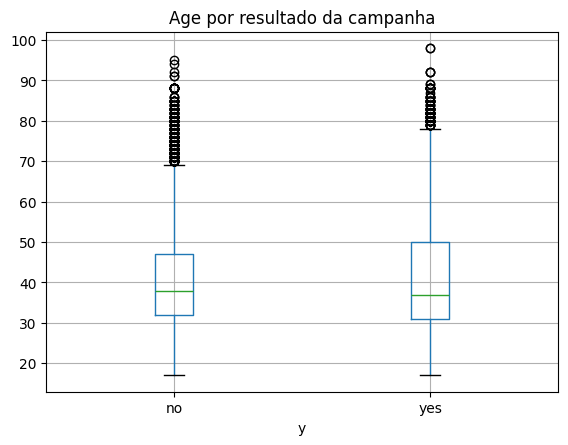

In [7]:
print('        Estatísticas por classe da variável target')
print('*' * 19 + " MÉDIA E MEDIANA " + '*' * 19)

print(df.groupby('y')['age'].agg(['mean','median']).T)
print()
print('*' * 25 + " IQR " + '*' * 25)
for classe in ['no', 'yes']: 
    dados = df[df['y'] == classe]['age'] 
 
    Q1 = dados.quantile(0.25) 
    Q3 = dados.quantile(0.75) 
    IQR = Q3 - Q1 
 
    limite_superior = Q3 + 1.5 * IQR 
 
    quantidade = (dados > limite_superior).sum()
    percentual_base = (quantidade / len(dados)) * 100

    print(f'{classe}:')
    print(f'  Total de registros: {len(dados)}')
    print(f'  Limite superior: {limite_superior:.2f}')
    print(f'  Possíveis outliers: {quantidade}')
    print(f'  Outliers em relação à base: {percentual_base:.2f}%')
    print()


df.boxplot(column='age', by='y')
plt.suptitle('')
plt.title('Age por resultado da campanha')
plt.show()

        Estatísticas por classe da variável target
******************* MÉDIA E MEDIANA *******************
y             no       yes
mean    2.633085  2.051724
median  2.000000  2.000000

************************* IQR *************************
no:
  Total de registros: 36548
  Limite superior: 6.00
  Possíveis outliers: 2295
  Outliers em relação à base: 6.28%

yes:
  Total de registros: 4640
  Limite superior: 3.50
  Possíveis outliers: 555
  Outliers em relação à base: 11.96%



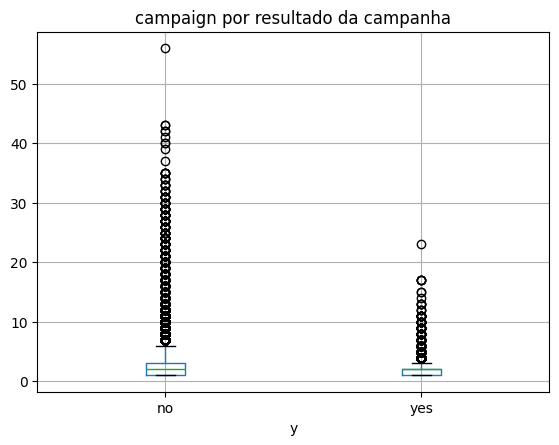

In [8]:
print('        Estatísticas por classe da variável target')
print('*' * 19 + " MÉDIA E MEDIANA " + '*' * 19)

print(df.groupby('y')['campaign'].agg(['mean','median']).T)
print()
print('*' * 25 + " IQR " + '*' * 25)
for classe in ['no', 'yes']: 
    dados = df[df['y'] == classe]['campaign'] 
 
    Q1 = dados.quantile(0.25) 
    Q3 = dados.quantile(0.75) 
    IQR = Q3 - Q1 
 
    limite_superior = Q3 + 1.5 * IQR 
 
    quantidade = (dados > limite_superior).sum()
    percentual_base = (quantidade / len(dados)) * 100

    print(f'{classe}:')
    print(f'  Total de registros: {len(dados)}')
    print(f'  Limite superior: {limite_superior:.2f}')
    print(f'  Possíveis outliers: {quantidade}')
    print(f'  Outliers em relação à base: {percentual_base:.2f}%')
    print()


df.boxplot(column='campaign', by='y')
plt.suptitle('')
plt.title('campaign por resultado da campanha')
plt.show()

### 1.8 Sobre as variáveis previous e poutcome, o que elas representam? Qual a relação delas com a taxa de yes no target?

Resposta:<br>
Previus, número de contatos realizado antes desta campanha.
Poutcome, Resultados da camanhap de mkt anterior.

```text
Analise:
             Target Y, (%) de YES por POUTCOME
poutcome                                      
failure                                  14.23
nonexistent                               8.83
success                                  65.11

          Target Y, (%) de YES por PREVIOUS
previous                                   
0                                      8.83
1                                     21.20
2                                     46.42
3                                     59.26
4                                     54.29
5                                     72.22
6                                     60.00
7                                      0.00
```

In [9]:
taxa_yes = (
    df.groupby('poutcome')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .round(2)
      .rename("Target Y, (%) de YES por POUTCOME")
)

print(taxa_yes.to_frame())

print()
taxa_yes = (
    df.groupby('previous')['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .round(2)
      .rename("Target Y, (%) de YES por PREVIOUS")
)

print(taxa_yes.to_frame())

             Target Y, (%) de YES por POUTCOME
poutcome                                      
failure                                  14.23
nonexistent                               8.83
success                                  65.11

          Target Y, (%) de YES por PREVIOUS
previous                                   
0                                      8.83
1                                     21.20
2                                     46.42
3                                     59.26
4                                     54.29
5                                     72.22
6                                     60.00
7                                      0.00


### 1.9 Qual a distribuição de registros por 'month'? Há sazonalidade? A taxa de 'yes' no target varia por 'month'? Mostre graficamente

Resposta:<br>
A distribuição dos registros por `month` é bem desigual. Mês de `may` concentra a maior parte dos registros representando aproximadamente 33.43% da base, seguido por ``jun`` 12.91%, ``jul`` 17.42% e ``aug`` 15.00%. Juntos, esses quatro meses representam mais de 78% do conjunto total.<br>
Ao analisar a taxa de yes por mês, também é possivel notar diferenças significativas. Porém, um detalhe importante é que o mês de `may`, onde foi constatado o maior numero de registro, representou a menor taxa de yes.


% distribuição de registro - `month`.
````text
month       
mar          1.33
apr          6.39
may         33.43
jun         12.91
jul         17.42
aug         15.00
sep          1.38
oct          1.74
nov          9.96
dec          0.44
````

% taxa de yes - `month`.
````text
month       
mar    50.55
apr    20.48
may     6.43
jun    10.51
jul     9.05
aug    10.60
sep    44.91
oct    43.87
nov    10.14
dec    48.90
````


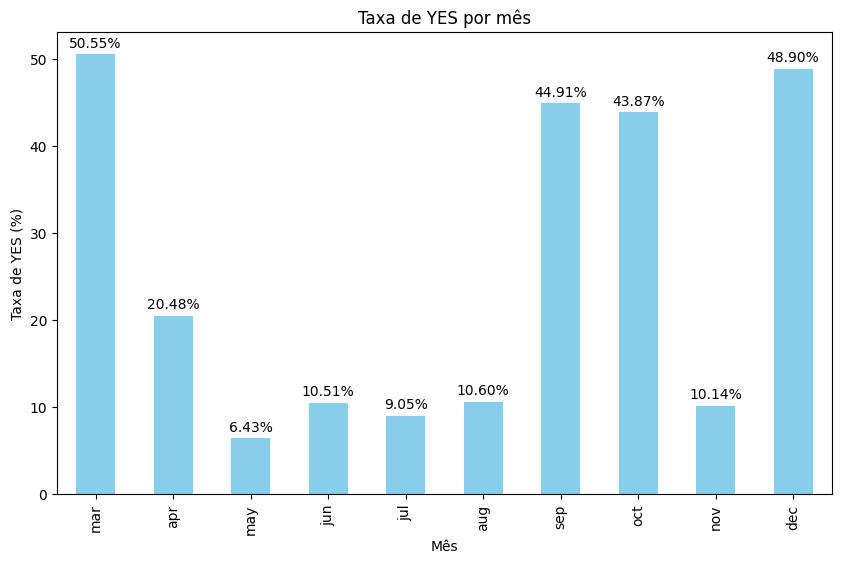

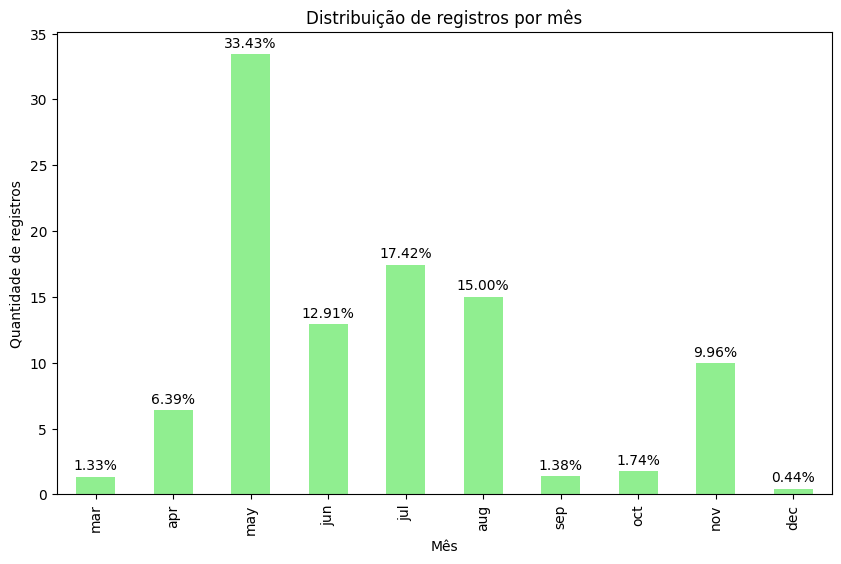

In [10]:
ordem_meses = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

taxa_mes = df.groupby('month')['y'].apply(
    lambda x: (x == 'yes').mean() * 100
).round(2)
taxa_mes = taxa_mes.reindex(ordem_meses).dropna()

aux0 = taxa_mes.plot(kind='bar', color='skyblue', figsize=(10, 6))
aux0.bar_label(aux0.containers[0], fmt='%.2f%%',padding=3)
plt.xlabel('Mês')
plt.ylabel('Taxa de YES (%)')
plt.title('Taxa de YES por mês')
plt.show()

print()

distribuicao_mes = df['month'].value_counts(normalize=True).mul(100).round(2)
distribuicao_mes = distribuicao_mes.reindex(ordem_meses).dropna()
aux1 = distribuicao_mes.plot(kind='bar', color='lightgreen', figsize=(10, 6))
aux1.bar_label(aux1.containers[0], fmt='%.2f%%',padding=3)
plt.xlabel('Mês')
plt.ylabel('Quantidade de registros')
plt.title('Distribuição de registros por mês')
plt.show()


### 1.10 Qual a correlação/taxa de 'yes' por faixa de 'duration'? Considerando o resultado obtido e a natureza da variável 'duration', ela deve entrar no treinamento dos modelos?

Resposta:
Quanto maior a duração da ligação, maior a proporção de YES.

````text
Duration      (%) YES
0-60            0.02
61-120          1.91
121-180         5.11
181-300        10.28
301-600        18.58
>600           48.61
````

In [11]:
faixas = [0, 60, 120, 180, 300, 600, float('inf')] # float('inf') significa infinitivo, ou seja numeros maior que 600 para esse caso
labels = ['0-60', '61-120', '121-180', '181-300', '301-600', '>600']

df_duration = df[['duration', 'y']].copy()

df_duration['duration_faixa'] = pd.cut(
    df_duration['duration'],
    bins=faixas,
    labels=labels,
    include_lowest=True
)

taxa_duration = (
    df_duration.groupby('duration_faixa', observed=True)['y']
      .apply(lambda x: (x == 'yes').mean() * 100)
      .round(2)
)

print(taxa_duration)

duration_faixa
0-60        0.02
61-120      1.91
121-180     5.11
181-300    10.28
301-600    18.58
>600       48.61
Name: y, dtype: float64


### 1.11 Existem colunas que incorporam informação “do futuro” ou pós-contato? Quais e por quê?

Resposta:
As variáveis `duration` e a target `y` incorporam informações relacionadas ao resultado do contato atual. `duration` representa a duração do contato durante ou após sua realização, pode causar data leakage. Já o `y` representa o resutlado da campanha e é a variavel target, não devendo se utilizada como feature.

## Parte 2 - Pré-processamento

Nesta Parte 2 (Pré-processamento) você vai transformar o "Bank Marketing" de uma base de dados bruta para uma pronta para modelagem. Isso inclui: remover variáveis inadequadas ao treino, decidir o split treino/teste e a forma de validação, tratar 'unknown', realizar balanceamento, etc. Ao final, você terá X_train, y_train, X_test, y_test e um preprocessador reutilizável para plugar diretamente nos modelos da Parte 3.

### 2.1 Qual é a lista final de colunas de entrada? Alguma deve ser removida? Justifique e remova-as caso necessário

Resposta:<br>
A feature ``duration`` será removida por representar uma informação pós-contato, podendo causar data leakage, conforme identificado na análise exploratória.

In [12]:
df_model = df.drop(columns=['duration'])

### 2.2 Existem linhas duplicadas? Se sim, o que fazer com elas?

Resposta:<br>
Foram identificados resgistos tanto na base original quanto na base com demoção da ``duration``. Porém em proporção expressivamente diferentes. Equanto o DataFrame original contém '12' regitros duplicados, a cópia do df sem a duration contém '1.784' duplicados.<br>
Em suma, como não há um identificador único disponível para determinar se essas observações representam o mesmo indivíduo, não é possível classificá-las como duplicatas reais. Portanto, os registros serão mantidos para evitar a exclusão indevida de observações potencialmente distintas.


In [13]:
df_duplicadas = df.duplicated().sum()
df_model_duplicadas = df_model.duplicated().sum()

print(f'Linhas duplicadas df original: {df_duplicadas}')
print(f'Linhas duplicadas df sem a coluna duration: {df_model_duplicadas}')


Linhas duplicadas df original: 12
Linhas duplicadas df sem a coluna duration: 1784


### 2.3 Em quais colunas categóricas aparece a categoria unknown? Qual a proporção por coluna? Você trataria unknown como categoria válida, imputaria ou agregaria? Justifique para as duas colunas com maior quantidade de unknown.

Resposta: <br>
As colunas com maior quantidade de ``unknown`` foram a ``default`` e ``education``. A ideia é manter todas as ocorrências como categoria válidas e, posteriormente, codificar asd features utilizando One-Hot Encoding, mantendo unknown como uma das categorias.


```text
job:
  Unknown: 330
  Proporção: 0.80%

marital:
  Unknown: 80
  Proporção: 0.19%

education:
  Unknown: 1731
  Proporção: 4.20%

default:
  Unknown: 8597
  Proporção: 20.87%

housing:
  Unknown: 990
  Proporção: 2.40%

loan:
  Unknown: 990
  Proporção: 2.40%
```

In [14]:
categoricas = df_model.select_dtypes(include="str")
for coluna in categoricas.columns:
    quantidade = (categoricas[coluna].str.lower() == 'unknown').sum()
    
    if quantidade > 0:
        percentual = quantidade / len(df_model) * 100
        
        print(f'{coluna}:')
        print(f'  Unknown: {quantidade}')
        print(f'  Proporção: {percentual:.2f}%')
        print()


job:
  Unknown: 330
  Proporção: 0.80%

marital:
  Unknown: 80
  Proporção: 0.19%

education:
  Unknown: 1731
  Proporção: 4.20%

default:
  Unknown: 8597
  Proporção: 20.87%

housing:
  Unknown: 990
  Proporção: 2.40%

loan:
  Unknown: 990
  Proporção: 2.40%



### 2.4 O que a variável pdays representa? Como ela precisa ser tratada no pré-processamento?

Resposta:
``pdays`` representa o número de dias decorridos desde o último contato com o cliente em uma campanha anterior. O valor ``999`` não representa literalmente ``999`` dias, mas indica que o cliente não foi contatado anteriormente.<br>
Como valor representa aproximadamente 96% da base, o ideal seria substituir o valor `999` por `nan`. Entretanto, para não perder a informação referente à existência de um contato anterior, será criada a variável ``previous_contact``, indicando por meio de 0 e 1 se o cliente já havia sido contatado anteriormente.



```` text
pdays  proportion
999    0.963217
3      0.010658
6      0.010003
4      0.002865
9      0.001554
2      0.001481
7      0.001457
12     0.001408
10     0.001263
5      0.001117
13     0.000874
11     0.000680
1      0.000631
15     0.000583
14     0.000486
8      0.000437
0      0.000364
16     0.000267
17     0.000194
18     0.000170
22     0.000073
19     0.000073
21     0.000049
25     0.000024
26     0.000024
27     0.000024
20     0.000024
````

In [15]:
df_model['previous_contact'] = (df_model['pdays'] != 999).astype(int) # coluna que indica se houve contato prévio 1
df_model['pdays'] = df_model['pdays'].replace(999, np.nan)

### 2.5 Existem outliers que precisam ser removidos? Justifique

Resposta:<br>
Não foram identificados outliers que justifiquem a remoção dos registros, conforme descrito nas análises acima.

### 2.6 Alguma variável precisa ser normalizada ou padronizada? Justifique

Resposta: <br>
As variáveis numéricas serão padronizadas utilizando o ``StandardScaler``, pois possuem escalas e amplitudes diferentes. Padronizar coloca elas numa escala comparável.<br>
Já as variáveis categóricas, serão transformadas em valores numéricos utilizando o ``OneHotEncoder``, não sendo necessário aplicar normalização ou padronização sobre elas.

In [16]:
# variaveis categóricas e numéricas
categoricas = df_model.select_dtypes(include='str').columns.drop('y')
numericas = df_model.select_dtypes(include='number').columns

# configuração do pré-processamento dos dados
preprocessor = ColumnTransformer(
    transformers=[
        ('categorias',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        ),
        ('nummericas',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]),numericas
        )
    ]
)


### 2.7 Faça a divisão treino/teste e construa X_train, X_test, y_train, y_test. (Cuidado com a divisão em treino/teste com séries temporais!)

Resposta:<br>
A base bank-additional-full é originalmente ordenada por data, abrangendo o período de maio de 2008 a novembro de 2010. Como a variável disponível no dataset registra apenas o mês, sem o ano, não é possível reconstruir diretamente a data completa a partir das features. 

Inicialmente, foi considerada uma divisão cronológica de aproximadamente 80% dos dados para treinamento e 20% para teste, preservando a ordem original dos registros. Entretanto, essa abordagem produziu uma distribuição significativamente diferente da variável-alvo entre os conjuntos de treinamento e teste.

Para evitar essa diferença de distribuição e garantir uma representação mais adequada das classes, foi utilizada a divisão estratificada dos dados, mantendo aproximadamente a mesma proporção da variável-alvo nos conjuntos de treinamento e teste.

````text
Ordem original da base:

may: 7,763 registros
jun: 4,374 registros
jul: 6,685 registros
aug: 5,175 registros
oct: 67 registros
nov: 3,616 registros
dec: 10 registros
mar: 282 registros
apr: 2,458 registros
may: 5,794 registros
jun: 715 registros
jul: 178 registros
aug: 770 registros
sep: 267 registros
oct: 447 registros
nov: 357 registros
dec: 172 registros
mar: 264 registros
apr: 174 registros
may: 212 registros
jun: 229 registros
jul: 311 registros
aug: 233 registros
sep: 303 registros
oct: 204 registros
nov: 128 registros

Total de registros: 41,188
Total esperado: 41,188
````


In [17]:
# Separação das variáveis preditoras (X) e target (y)
X = df_model.drop(columns='y')
y = df_model['y'].map({'no': 0,'yes': 1})

# Divisão treino/teste mantendo a proporção das classes
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


### 2.8 Se achar necessário, adicione aqui alguma atividade de pré-processamento para melhorar o desempenho dos modelos a serem treinados

Resposta:<br>
Na etapa 2.4 foi adicionado uma coluna a mais, ``previous_contact``, acredito que ela teve relevância no projeto.

## Parte 3 - Treinando e Avaliando os Modelos

Nesta etapa você treinará os modelos usando exclusivamente o conjunto de treino. O foco aqui é treinar modelos das técnicas vistas em sala de aula (Árvore de Decisão, Bagging, Random Forest, AdaBoost, Gradient Boosting, XGBoost) para predizer a variável target. Depois, usando o conjunto de teste, deve-se avaliar o desempenho de cada modelo.

O que será avaliado?
 - Se todos os modelos foram treinados corretamente
 - Se as métricas de desempenho (Matriz de confusão, Acurácia, Precisão, Recall, F1-Score, ROC AUC, PR AUC, etc.) foram calculadas
 - Se uma grid search (pode ser algo curto, 2 a 10 valores, por exemplo) foi feita para pelo menos um dos hiperparâmetros de cada modelo
 - Se o código está bem comentado, explicando o seu funcionamento
 
 OBS: Pontuação extra será dada para os alunos que realizarem testes ou implementarem estratégias além da minimamente exigida para melhorar o desempenho dos modelos. Figuras e gráficos ilustrativos, para ajudar na interpretação de modelos e resultados, também marcam pontos extras


In [35]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from sklearn.impute import SimpleImputer

# Identifica as posições das variáveis categóricas
categoricas = X_train.select_dtypes(include='object').columns

categoricas_indices = [
    X_train.columns.get_loc(coluna) for coluna in categoricas
]

# Trata valores ausentes antes do SMOTENC
X_train = X_train.copy()

for coluna in categoricas:
    X_train[coluna] = X_train[coluna].fillna(
        X_train[coluna].mode()[0]
    )

for coluna in X_train.select_dtypes(include='number').columns:
    X_train[coluna] = X_train[coluna].fillna(
        X_train[coluna].median()
    )


# Modelos de classificação
modelos_smote = {
    "Random Forest": RandomForestClassifier(random_state=42),

    "Bagging": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(random_state=42),

    "Gradient Boosting": GradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(random_state=42)
}


# Hiperparâmetros
parametros_smote = {

    "Random Forest": {
        "model__n_estimators": [2, 4, 6, 8, 10]
    },

    "XGBoost": {
        "model__n_estimators": [2, 4, 6, 8, 10]
    },

    "Bagging": {
        "model__n_estimators": [2, 4, 6, 8, 10]
    },

    "AdaBoost": {
        "model__n_estimators": [2, 4, 6, 8, 10]
    },

    "Gradient Boosting": {
        "model__n_estimators": [2, 4, 6, 8, 10]
    }
}


# Time Series Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)

resultados_grids_smote = {}


for nome, modelo_base in modelos_smote.items():

    print(f"Treinando modelo com SMOTE: {nome}")

    modelo = Pipeline([

        # Reduz a classe majoritária
        ('undersampling', RandomUnderSampler(
            random_state=42,
            sampling_strategy=0.5
        )),

        # Aumenta a classe minoritária
        ('smote', SMOTENC(
            categorical_features=categoricas_indices,
            random_state=42,
            sampling_strategy=1.0
        )),

        # Pré-processamento
        ('preprocessor', preprocessor),

        ('model', modelo_base)
    ])

    grid = GridSearchCV(
        modelo,
        param_grid=parametros_smote[nome],
        cv=tscv,
        scoring='f1',
        n_jobs=1,
        return_train_score=True
    )

    grid.fit(X_train, y_train)

    resultados_grids_smote[nome] = {
        'grid': grid,
        'melhor_modelo': grid.best_estimator_,
        'melhores_parametros': grid.best_params_,
        'melhor_f1': grid.best_score_,
        'resultados': pd.DataFrame(grid.cv_results_)
    }

C:\Users\ander\AppData\Local\Temp\ipykernel_4388\3656644659.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = X_train.select_dtypes(include='object').columns


Treinando modelo com SMOTE: Random Forest
Treinando modelo com SMOTE: Bagging
Treinando modelo com SMOTE: AdaBoost
Treinando modelo com SMOTE: Gradient Boosting
Treinando modelo com SMOTE: XGBoost


In [36]:
print("RANDOM FOREST: ")
resultados_rf = resultados_grids_smote["Random Forest"]["resultados"]

print(
    resultados_rf[
        [
            "param_model__n_estimators",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
        ]
    ].to_string(index=False)
)

RANDOM FOREST: 
 param_model__n_estimators  mean_train_score  mean_test_score  std_test_score
                         2          0.591243         0.355690        0.017790
                         4          0.635658         0.385885        0.017582
                         6          0.648756         0.396407        0.021979
                         8          0.658909         0.403007        0.016136
                        10          0.667105         0.408640        0.015221


In [37]:
print("BAGGING:")
resultados_bagging = resultados_grids_smote["Bagging"]["resultados"]

print(
    resultados_bagging[
        [
            "param_model__n_estimators",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
        ]
    ].to_string(index=False)
)

BAGGING:
 param_model__n_estimators  mean_train_score  mean_test_score  std_test_score
                         2          0.592830         0.341801        0.009648
                         4          0.629742         0.373110        0.010904
                         6          0.649169         0.380167        0.017961
                         8          0.657086         0.391994        0.019864
                        10          0.662879         0.395730        0.022709


In [38]:
print("ADABOOST:")
resultados_adaboost = resultados_grids_smote["AdaBoost"]["resultados"]

print(
    resultados_adaboost[
        [
            "param_model__n_estimators",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
        ]
    ].to_string(index=False)
)

ADABOOST:
 param_model__n_estimators  mean_train_score  mean_test_score  std_test_score
                         2          0.463908         0.455430        0.015978
                         4          0.388330         0.382813        0.024726
                         6          0.393485         0.388393        0.024267
                         8          0.398471         0.390162        0.023815
                        10          0.413380         0.406219        0.016860


In [40]:

print("GRADIENT BOOSTING:")
resultados_gb = resultados_grids_smote["Gradient Boosting"]["resultados"]

print(
    resultados_gb[
        [
            "param_model__n_estimators",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
        ]
    ].to_string(index=False)
)

GRADIENT BOOSTING:
 param_model__n_estimators  mean_train_score  mean_test_score  std_test_score
                         2          0.448842         0.440278        0.013489
                         4          0.455283         0.447372        0.008936
                         6          0.457345         0.446446        0.008944
                         8          0.456339         0.445614        0.010151
                        10          0.458439         0.447797        0.008603


In [41]:
print("XGBOOST :")


resultados_xgb = resultados_grids_smote["XGBoost"]["resultados"]

print(
    resultados_xgb[
       [
            "param_model__n_estimators",
            "mean_train_score",
            "mean_test_score",
            "std_test_score"
        ]
    ].to_string(index=False)
)

XGBOOST :
 param_model__n_estimators  mean_train_score  mean_test_score  std_test_score
                         2          0.494716         0.454662        0.011520
                         4          0.508134         0.464263        0.009132
                         6          0.504131         0.459823        0.008403
                         8          0.501482         0.453054        0.012019
                        10          0.502022         0.451727        0.011473


In [42]:
## ROC-AUC - dois melhores modelos: Random Forest e XGBoost
# Random Forest
rf = resultados_grids_smote['Random Forest']['melhor_modelo']
y_prob_rf = rf.predict_proba(X_test)[:, 1]
roc_rf = roc_auc_score(y_test, y_prob_rf)

# XGBoost
xgb = resultados_grids_smote['XGBoost']['melhor_modelo']
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
roc_xgb = roc_auc_score(y_test, y_prob_xgb)


print(f"Random Forest ROC-AUC: {roc_rf:.4f}")
print(f"XGBoost ROC-AUC:       {roc_xgb:.4f}")

Random Forest ROC-AUC: 0.7656
XGBoost ROC-AUC:       0.7994


In [43]:
## PR-AUC - dois melhores modelos: Random Forest e XGBoost
# Random Forest
pr_rf = average_precision_score(
    y_test,
    rf.predict_proba(X_test)[:, 1]
)
# XGBoost
pr_xgb = average_precision_score(
    y_test,
    xgb.predict_proba(X_test)[:, 1]
)

print(f"Random Forest PR-AUC: {pr_rf:.4f}")
print(f"XGBoost PR-AUC:       {pr_xgb:.4f}")

Random Forest PR-AUC: 0.3550
XGBoost PR-AUC:       0.4547


In [44]:
## Lift - dois melhores modelos: Random Forest e XGBoost
# RANDOM FOREST
# Probabilidade da classe positiva (yes)
print("Random Forest:")
y_prob_rf = rf.predict_proba(X_test)[:, 1]

df_lift_rf = pd.DataFrame({
    'y_real': y_test.values,
    'probabilidade': y_prob_rf
})

# Ordena do maior para o menor score
df_lift_rf = df_lift_rf.sort_values(
    'probabilidade',
    ascending=False
).reset_index(drop=True)

# Divide em 10 grupos
df_lift_rf['decil'] = pd.qcut(
    df_lift_rf['probabilidade'],
    10,
    labels=False,
    duplicates='drop' # O parâmetro duplicates='drop' remove os limites de corte
)

# Coloca o decil 10 como maior probabilidade
# Quando existem muitos valores de probabilidade iguais,
# o pandas pode gerar menos de 10 grupos.
# O parâmetro duplicates='drop' remove os limites de corte
# duplicados para evitar erros.
df_lift_rf['decil'] = 10 - df_lift_rf['decil'] 

# Calcula taxa de positivos em cada decil
lift_rf = (
    df_lift_rf
    .groupby('decil')
    .agg(
        quantidade=('y_real', 'count'),
        positivos=('y_real', 'sum'),
        taxa_positivos=('y_real', 'mean')
    )
    .reset_index()
)

# Taxa de positivos da população inteira
taxa_populacao_rf = df_lift_rf['y_real'].mean()

# Lift
lift_rf['lift'] = (
    lift_rf['taxa_positivos'] / taxa_populacao_rf
)

print(lift_rf)
print()

# XGBoost
print("XGBoost:")
# Probabilidade da classe positiva (yes)
y_prob = xgb.predict_proba(X_test)[:, 1]

df_lift = pd.DataFrame({
    'y_real': y_test.values,
    'probabilidade': y_prob
})

# Ordena do maior para o menor score
df_lift = df_lift.sort_values(
    'probabilidade',
    ascending=False
).reset_index(drop=True)

# Divide em 10 grupos
df_lift['decil'] = pd.qcut(
    df_lift['probabilidade'],
    10,
    labels=False,
    duplicates='drop'
)

# Coloca o decil 10 como maior probabilidade
df_lift['decil'] = 10 - df_lift['decil']

# Calcula taxa de positivos em cada decil
lift = (
    df_lift
    .groupby('decil')
    .agg(
        quantidade=('y_real', 'count'),
        positivos=('y_real', 'sum'),
        taxa_positivos=('y_real', 'mean')
    )
    .reset_index()
)

# Taxa de positivos da população inteira
taxa_populacao = df_lift['y_real'].mean()

# Lift
lift['lift'] = lift['taxa_positivos'] / taxa_populacao

print(lift)

Random Forest:
   decil  quantidade  positivos  taxa_positivos      lift
0      4         598        302        0.505017  4.483112
1      5        1050        253        0.240952  2.138972
2      6         564         57        0.101064  0.897159
3      7         759         58        0.076416  0.678360
4      8        1077         63        0.058496  0.519276
5      9        1375         59        0.042909  0.380911
6     10        2815        136        0.048313  0.428879

XGBoost:
   decil  quantidade  positivos  taxa_positivos      lift
0      1         758        415        0.547493  4.860184
1      2         872        184        0.211009  1.873161
2      3         618         59        0.095469  0.847495
3      4         820         39        0.047561  0.422206
4      5        1009         60        0.059465  0.527878
5      6         802         50        0.062344  0.553439
6      7         819         33        0.040293  0.357688
7      8         886         31        0.034989

In [45]:
# Modelo vencedor
# XGBost
print("=" * 50)
print("XGBoost")
print("Modelo selecionado para a avaliação final.")
print("=" * 50)

modelo_final = resultados_grids_smote['XGBoost']['melhor_modelo']

y_pred = modelo_final.predict(X_test)
y_prob = modelo_final.predict_proba(X_test)[:, 1]

acuracia = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print(f"\nAcurácia: {acuracia:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"PR-AUC:   {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=['no', 'yes']
))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


XGBoost
Modelo selecionado para a avaliação final.

Acurácia: 0.8511
ROC-AUC:  0.7994
PR-AUC:   0.4547

Classification Report:
              precision    recall  f1-score   support

          no       0.95      0.88      0.91      7310
         yes       0.40      0.63      0.49       928

    accuracy                           0.85      8238
   macro avg       0.67      0.76      0.70      8238
weighted avg       0.89      0.85      0.87      8238

Matriz de Confusão:
[[6422  888]
 [ 339  589]]


## Parte 4 - Conclusões

O objetivo desta etapa final é interpretar resultados, refletir sobre o pré-processamento e consolidar recomendações.

### 4.1 Quais métricas de desempenho são mais relevantes, neste caso, para comparar os diferentes modelos?

Resposta:<br>
As métricas mais relevantes foram ``F1-score``, ``ROC-AUC``, ``PR-AUC`` e ``Lift``.

O F1-score foi utilizado no GridSearch para selecionar os melhores hiperparâmetros de cada modelo. Após a seleção dos dois melhores modelos, Random Forest e XGBoost, foram utilizadas ROC-AUC, PR-AUC e Lift para uma comparação mais aprofundada.

Entre elas, o Lift foi especialmente relevante, pois permitiu visualizar o ganho do modelo na identificação e priorização dos clientes da classe positiva.

### 4.2 Qual modelo obteve os melhores AP (PR AUC) e ROC AUC no teste?

Resposta:<br>
O XGBoost obteve os Melhores resultados de Avarege Precision ``PR-AUC`` de 0.4886 e ``ROC-AUC`` de 0.8123.  

### 4.3 Dentre todos os modelos treinados, indique o que teve o melhor desempenho (descreva o tipo e hiperparâmetros). Justifique a sua escolha

Resposta:<br>
O modelo escolhido foi o XGBoost, com os hiperparâmetros selecionados pelo GridSearch. Após adicionar balanceamento de classes `` "model__scale_pos_weight": [1, 14.69]  `` o modelo apresentou o melhor desempenho entre os finalistas, melhor substanciamente a taxa de ``PR-AUC`` e ``ROC-AUC``, além de apresentar bom desempenho na identificação da classe positiva. Por esses resultados, o XGBoost foi selecionado como modelo final.


### 4.4 Na sua opinião, qual etapa, de todas as executadas para a obtenção dos resultados, foi mais decisiva e qual foi a mais trabalhosa? O que você faria diferente em um próximo projeto?

Resposta:<br>
A etapa mais decisiva foi a separação do dataset. Nela, foi necessário analisar a distribuição das classes para garantir uma avaliação adequada dos modelos. Nos primeiros testes, o F1-score da classe positiva ficou muito baixo, não chegando a 10%, devido à diferença na distribuição das classes entre os conjuntos de treino e teste. depois que ajustei/mudei a estratégia de separação, os resultados dos modelos se tornaram mais consistentes.

A etapa mais trabalhosa foi a comparação e avaliação dos modelos, principalmente durante o GridSearch e a análise das diferentes métricas.

Em um próximo projeto, eu dedicaria mais tempo inicial analisando estrutura e distribuição dos dados, para definir a estratégia de validação antes de iniciar o treinamento dos modelos - o que aconteceu indiretamente nesse.

